## ASSIGNMENT NO:5(b)

Name:Nikam Sakshi Jalindar

Roll No:2317085



In [1]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [25]:
# Load dataset
data = pd.read_csv("combined_employee_dataset_1.csv")
data

,age,years_experience,education_level,department,performance_score,performance_category
0,58,23,High School,Finance,10,Excellent
1,48,39,Bachelor,HR,6,Good
2,34,15,High School,HR,5,Average
3,27,29,PhD,HR,4,Average
4,40,36,PhD,Finance,2,Poor
...,...,...,...,...,...,...
786,21,19,Bachelor,Sales,9,Very Good
787,25,4,Master,Finance,4,Average
788,47,35,Bachelor,Finance,6,Good
789,47,17,High School,Sales,1,Poor


In [27]:
data.head()

,age,years_experience,education_level,department,performance_score,performance_category
0,58,23,High School,Finance,10,Excellent
1,48,39,Bachelor,HR,6,Good
2,34,15,High School,HR,5,Average
3,27,29,PhD,HR,4,Average
4,40,36,PhD,Finance,2,Poor


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   791 non-null    int64 
 1   years_experience      791 non-null    int64 
 2   education_level       791 non-null    object
 3   department            791 non-null    object
 4   performance_score     791 non-null    int64 
 5   performance_category  791 non-null    object
dtypes: int64(3), object(3)
memory usage: 37.2+ KB


In [31]:
data.describe()

,age,years_experience,performance_score
count,791.000000,791.000000,791.000000
mean,39.867257,21.031606,5.495575
std,11.867681,11.467412,2.927766
min,20.000000,1.000000,1.000000
25%,29.000000,11.000000,3.000000
50%,41.000000,22.000000,5.000000
75%,51.000000,32.000000,8.000000
max,59.000000,39.000000,10.000000


In [33]:
data.isnull().sum()

age                     0
years_experience        0
education_level         0
department              0
performance_score       0
performance_category    0
dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'years_experience'}>],
       [<Axes: title={'center': 'performance_score'}>, <Axes: >]],
      dtype=object)

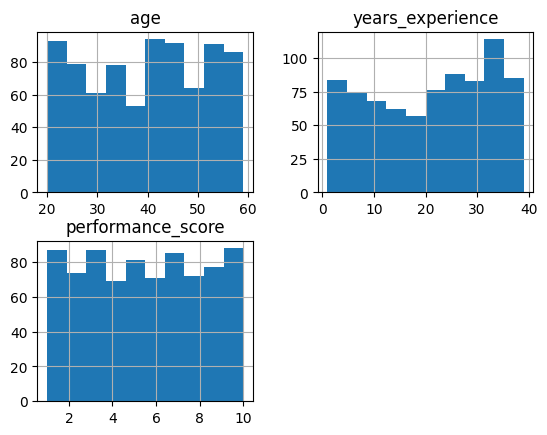

In [35]:
data.hist()

In [5]:
# Create Bias label
# 1 = Biased, 0 = Not Biased
data['bias'] = data['performance_score'].apply(lambda x: 1 if x <= 4 else 0)

In [7]:
# Encode categorical columns
le1 = LabelEncoder()
le2 = LabelEncoder()

data['education_level'] = le1.fit_transform(data['education_level'])
data['department'] = le2.fit_transform(data['department'])

In [9]:
# Features and target
X = data[['age', 'years_experience', 'education_level', 'department']]
y = data['bias']

In [11]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [15]:
# Prediction
y_pred = model.predict(X_test)

In [17]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5345911949685535


In [19]:
# Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.66      0.63        96
           1       0.40      0.35      0.37        63

    accuracy                           0.53       159
   macro avg       0.50      0.50      0.50       159
weighted avg       0.52      0.53      0.53       159



In [21]:
# Test with new employee data
new_employee = [[35, 8, 2, 1]]  
prediction = model.predict(new_employee)

if prediction[0] == 1:
    print("Prediction: Biased Evaluation")
else:
    print("Prediction: Not Biased")

Prediction: Not Biased


/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
